In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gaussian_kde
import warnings
import math
warnings.filterwarnings('ignore')
%matplotlib inline

In [89]:
df1 = pd.read_csv('heart.csv')

# Description of the Heart Failure Prediction Dataset  
The dataset aims to clinical features for predicting heart disease events.
## The Structure of the Dataset
1. **Age**: age of the patient [years]
2. **Sex**: sex of the patient [M: Male, F: Female]
3. **ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. **RestingBP**: resting blood pressure [mm Hg]
5. **Cholesterol**: serum cholesterol [mm/dl]
6. **FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. **RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. **MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]
9. **ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]
10. **Oldpeak**: oldpeak = ST [Numeric value measured in depression]
11. **ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. **HeartDisease**: output class [1: heart disease, 0: Normal]



In [90]:
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Quality Control

In [91]:
summary_data = []
for col in df1.columns:
    summary_data.append({
        'Column_Name': col,
        'Type': str(df1[col].dtype),
        'Unique_Values': df1[col].unique().tolist()
    })

df_info = pd.DataFrame(summary_data)
print(df_info)

       Column_Name     Type                                      Unique_Values
0              Age    int64  [40, 49, 37, 48, 54, 39, 45, 58, 42, 38, 43, 6...
1              Sex   object                                             [M, F]
2    ChestPainType   object                                [ATA, NAP, ASY, TA]
3        RestingBP    int64  [140, 160, 130, 138, 150, 120, 110, 136, 115, ...
4      Cholesterol    int64  [289, 180, 283, 214, 195, 339, 237, 208, 207, ...
5        FastingBS    int64                                             [0, 1]
6       RestingECG   object                                  [Normal, ST, LVH]
7            MaxHR    int64  [172, 156, 98, 108, 122, 170, 142, 130, 120, 9...
8   ExerciseAngina   object                                             [N, Y]
9          Oldpeak  float64  [0.0, 1.0, 1.5, 2.0, 3.0, 4.0, 0.5, 2.5, 5.0, ...
10        ST_Slope   object                                   [Up, Flat, Down]
11    HeartDisease    int64                         

df1.isnull()

In [92]:
df1.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [93]:
df1.duplicated().sum()

0

From the tables, we can see that the values for the ordinal and categorical variables are consistent with the dataset description, and there are no missing values. There are also no duplicated rows.  

Let us now take a closer look at the continuous variables.

In [94]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for i in cols:
    print(f"Non-numerical values in {i}: {df1[i].isna().sum()}")

Non-numerical values in Age: 0
Non-numerical values in RestingBP: 0
Non-numerical values in Cholesterol: 0
Non-numerical values in MaxHR: 0
Non-numerical values in Oldpeak: 0


There are no non-numerical values in the columns with continuous data, so now we can identify some common characteristics of our dataset's continuous data.

In [95]:
continuous_summary = df1[cols].agg(['min', 'max', 'mean', 'median', 'std']).T

continuous_summary.index.name = 'Variable'
continuous_summary = continuous_summary.reset_index()

print(continuous_summary)

      Variable   min    max        mean  median         std
0          Age  28.0   77.0   53.510893    54.0    9.432617
1    RestingBP   0.0  200.0  132.396514   130.0   18.514154
2  Cholesterol   0.0  603.0  198.799564   223.0  109.384145
3        MaxHR  60.0  202.0  136.809368   138.0   25.460334
4      Oldpeak  -2.6    6.2    0.887364     0.6    1.066570


RestinBP and Cholesterol contains zero values which is not possible for an alive human and may influence the further analysis. Let's investigate these values.

In [96]:
for i in cols[1:3]:
    zero_count = (df1[i] == 0).sum()
    percentage = round((zero_count / len(df1)) * 100, 2)
    
    print(f"Zero values in {i:12}: {zero_count:<5} | Percentage: {percentage}%")

Zero values in RestingBP   : 1     | Percentage: 0.11%
Zero values in Cholesterol : 172   | Percentage: 18.74%


In [97]:
df1.loc[df1['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


For RestingBP only 1 value is zero so we can either omit it or substitute with the median value for this clinical feature.

In [98]:
bp_median = df1[df1['RestingBP'] > 0]['RestingBP'].median()
df1['RestingBP'] = df1['RestingBP'].replace(0, bp_median)
print(f"RestingBP zero replaced with median: {bp_median}")
df_final = df1.copy()

RestingBP zero replaced with median: 130.0


In [99]:
df1.loc[df1['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


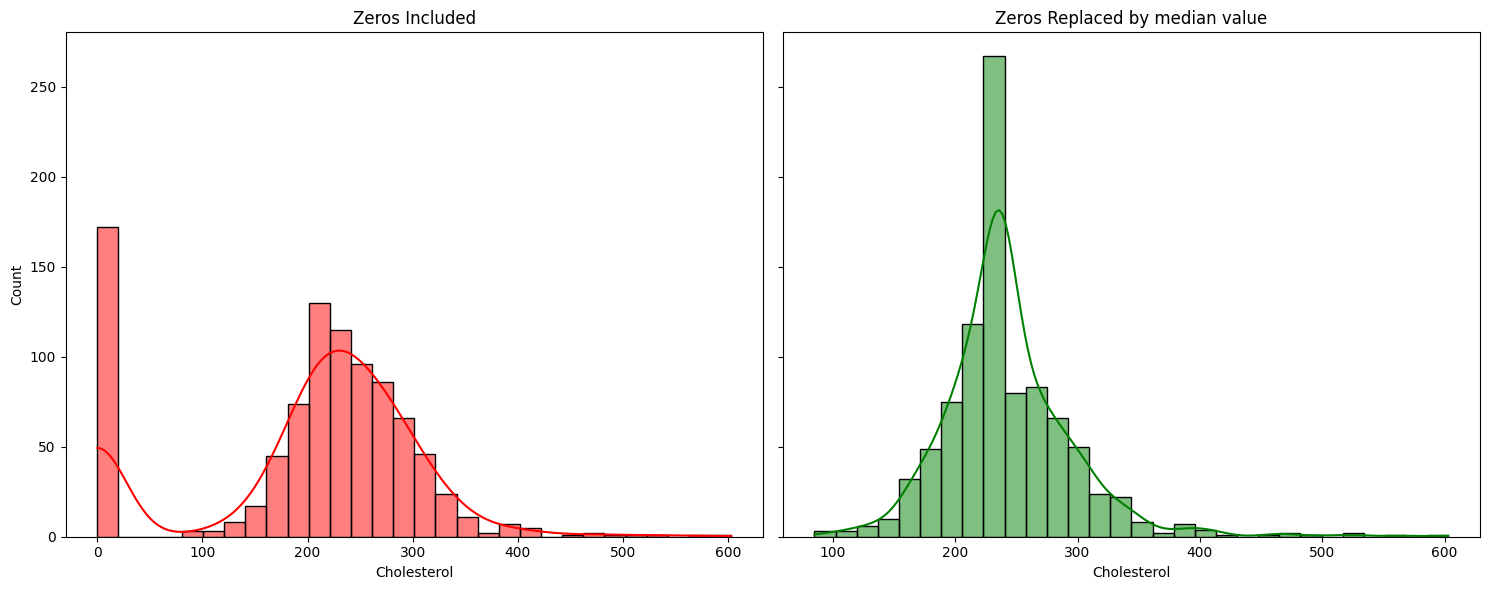

In [100]:
chol_before = df1['Cholesterol'].copy()

median_val = df1.loc[df1['Cholesterol'] != 0, 'Cholesterol'].median()
chol_after = df1['Cholesterol'].replace(0, median_val)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.histplot(chol_before, kde=True, ax=axes[0], color='red', bins=30)
axes[0].set_title(f"Zeros Included")
axes[0].set_xlabel("Cholesterol")

sns.histplot(chol_after, kde=True, ax=axes[1], color='green', bins=30)
axes[1].set_title(f"Zeros Replaced by median value")
axes[1].set_xlabel("Cholesterol")

plt.tight_layout()
plt.show()

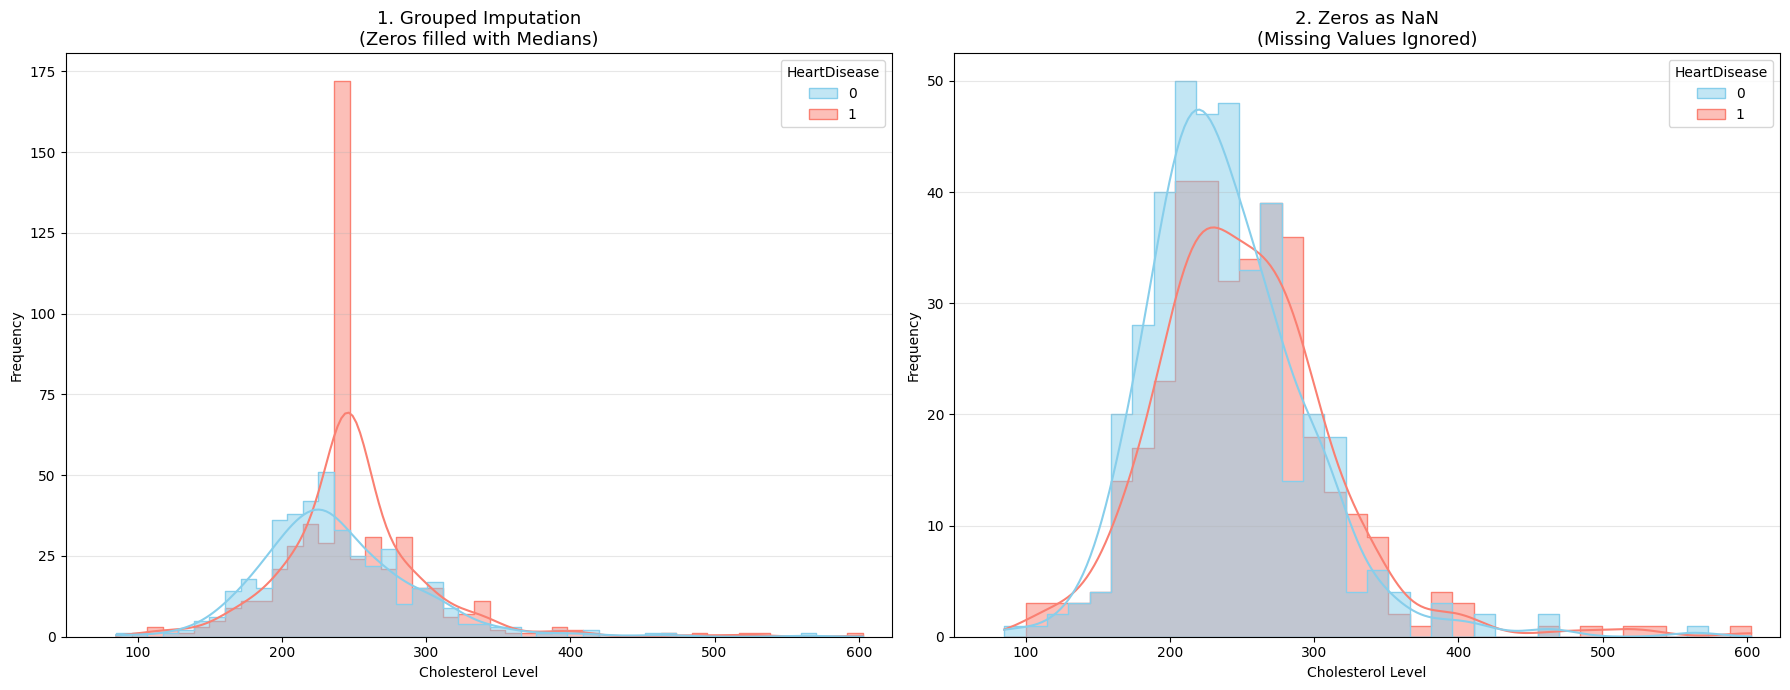

In [101]:
df_imputed = df1.copy()
median_healthy = df_imputed[(df_imputed['HeartDisease'] == 0) & (df_imputed['Cholesterol'] != 0)]['Cholesterol'].median()
median_affected = df_imputed[(df_imputed['HeartDisease'] == 1) & (df_imputed['Cholesterol'] != 0)]['Cholesterol'].median()

df_imputed.loc[(df_imputed['HeartDisease'] == 0) & (df_imputed['Cholesterol'] == 0), 'Cholesterol'] = median_healthy
df_imputed.loc[(df_imputed['HeartDisease'] == 1) & (df_imputed['Cholesterol'] == 0), 'Cholesterol'] = median_affected

df_nan = df1.copy()
df_nan['Cholesterol'] = df_nan['Cholesterol'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(data=df_imputed, x='Cholesterol', hue='HeartDisease', kde=True, 
             element="step", palette={0: 'skyblue', 1: 'salmon'}, alpha=0.5, ax=axes[0])
axes[0].set_title("1. Grouped Imputation\n(Zeros filled with Medians)", fontsize=13)
axes[0].set_xlim(50, df1['Cholesterol'].max() + 20)


sns.histplot(data=df_nan, x='Cholesterol', hue='HeartDisease', kde=True, 
             element="step", palette={0: 'skyblue', 1: 'salmon'}, alpha=0.5, ax=axes[1])
axes[1].set_title("2. Zeros as NaN\n(Missing Values Ignored)", fontsize=13)
axes[1].set_xlim(50, df1['Cholesterol'].max() + 20)

for ax in axes:
    ax.set_xlabel("Cholesterol Level")
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The plots indicate that zero values significantly distort the distribution of the cholesterol feature, and imputing these values with the mean also affects the results. Therefore, the most appropriate approach is likely to exclude these values when performing the analysis or building a model.

# The Structure of Study Population

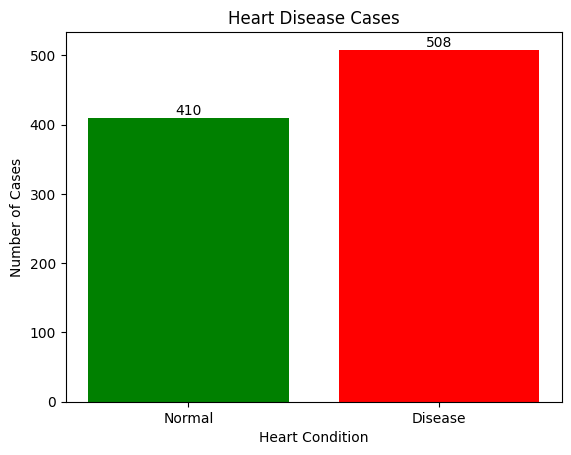

In [102]:
counts = df1["HeartDisease"].value_counts().sort_index()

labels = ["Normal", "Disease"]

colors = ["green", "red"]

bars = plt.bar(labels, counts.values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center', va='bottom'
    )

plt.xlabel('Heart Condition')
plt.ylabel("Number of Cases")
plt.title("Heart Disease Cases")
plt.show()


The dataset shows the study of traits associated with heart failure of **918 people in total**:

* **410 are healthy** (in terms of heart conditions);

* **508 are having heart disease**.

Let's take a closer look at the structure of both groups.


## Sex Structure

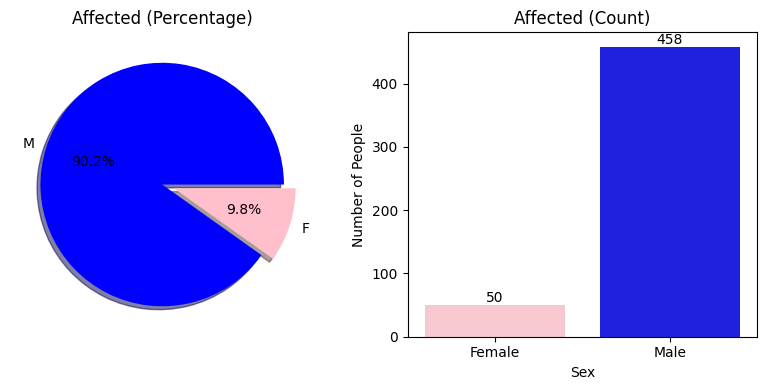

In [103]:
affected = df1[df1["HeartDisease"] == 1]
f, ax = plt.subplots(1, 2, figsize=(8, 4))

affected['Sex'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    colors= ['blue', 'pink']
)

ax[0].set_title('Affected (Percentage)')
ax[0].set_ylabel('')

sns.countplot(
    data=affected,
    x='Sex',
    ax=ax[1],
    palette = ['pink', 'blue']
)

ax[1].set_title('Affected (Count)')
ax[1].set_xlabel('Sex')
ax[1].set_ylabel('Number of People')

ax[1].set_xticklabels(["Female", "Male"])

for p in ax[1].patches:
    ax[1].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

We can see that the **percentage of affected men is significantly higher** than that of women.  
**Among the affected population, 90.2% are men, representing 458 individuals**. This suggests that **the risk of heart failure is much higher in men**.

The youngest studied individual: 28 years
The oldest studied individual: 77 years
The average age of healthy individuals: 50.55 years
The average age of affected individuals: 55.9 years
The median age of affected individuals: 57.0 years


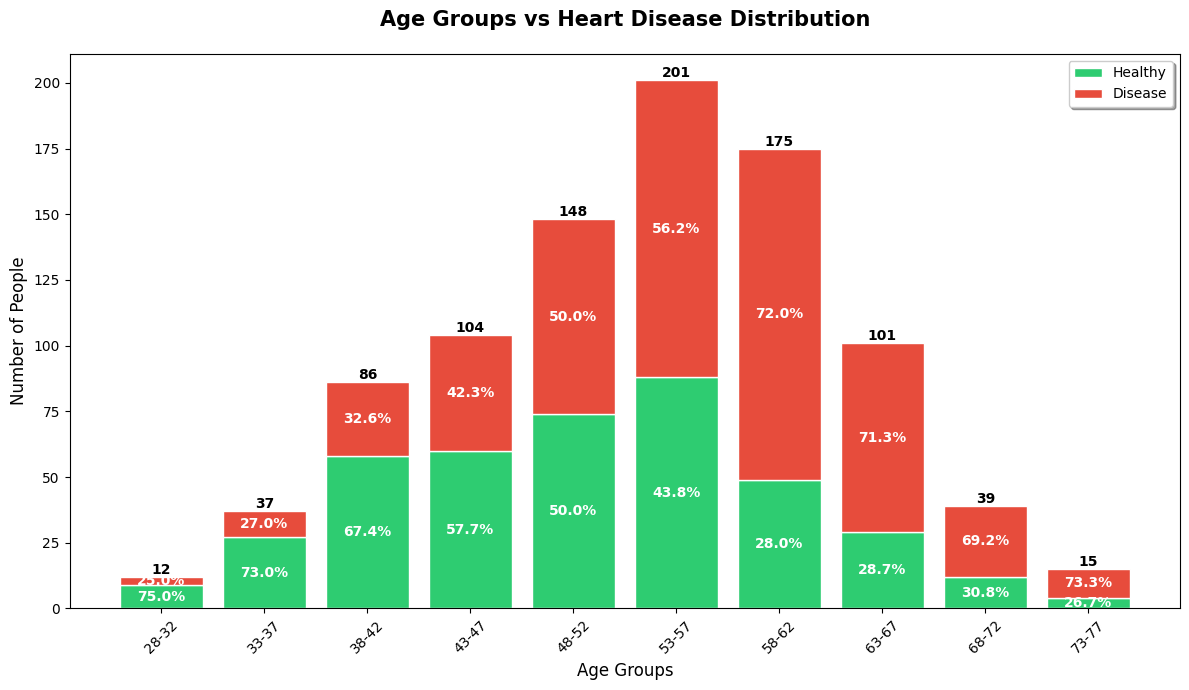

In [104]:
df_plot = df1.copy()

print(f'The youngest studied individual: {round(min(df_plot["Age"]), 2)} years')
print(f'The oldest studied individual: {round(max(df_plot["Age"]), 2)} years')
print(f"The average age of healthy individuals: {round(df_plot.loc[df_plot['HeartDisease'] == 0, 'Age'].mean(), 2)} years")
print(f"The average age of affected individuals: {round(df_plot.loc[df_plot['HeartDisease'] == 1, 'Age'].mean(), 2)} years")
print(f"The median age of affected individuals: {df_plot.loc[df_plot['HeartDisease'] == 1, 'Age'].median()} years")

step = 5
min_age = int(df_plot["Age"].min())
max_age = int(df_plot["Age"].max())
bins = np.arange(min_age, max_age + step, step)
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

df_plot["AgeGroup"] = pd.cut(df_plot["Age"], bins=bins, labels=labels, right=False)

grouped_bar = df_plot.groupby(["AgeGroup", "HeartDisease"], observed=False).size().unstack(fill_value=0)
healthy = grouped_bar.get(0, pd.Series([0]*len(grouped_bar))) 
disease = grouped_bar.get(1, pd.Series([0]*len(grouped_bar)))

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(grouped_bar.index))

ax.bar(x, healthy, color='#2ecc71', label='Healthy', edgecolor='white') # Green
ax.bar(x, disease, bottom=healthy, color='#e74c3c', label='Disease', edgecolor='white') # Red

for i in range(len(x)):
    h_val = healthy.iloc[i]
    d_val = disease.iloc[i]
    total = h_val + d_val
    
    if total > 0:
        ax.text(x[i], total, int(total), ha='center', va='bottom', fontweight='bold')
        
        if h_val > 0:
            ax.text(x[i], h_val/2, f"{(h_val/total)*100:.1f}%", 
                    ha='center', va='center', color='white', fontweight='bold')
        
        if d_val > 0:
            ax.text(x[i], h_val + d_val/2, f"{(d_val/total)*100:.1f}%", 
                    ha='center', va='center', color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(grouped_bar.index, rotation=45)
ax.set_xlabel("Age Groups", fontsize=12)
ax.set_ylabel("Number of People", fontsize=12)
ax.set_title("Age Groups vs Heart Disease Distribution", fontsize=15, fontweight='bold', pad=20)
ax.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

The dataset includes individuals aged 28 to 77 years. The analysis shows that the number of patients with heart disease increases after the age of 38. Furthermore, **the proportion of individuals affected by heart disease exceeds 50% in each age group above 48**, reaching a maximum of **73.3% in the oldest group**. This suggests that the development of heart failure is associated with age and that age is an important risk factor for the disease.  

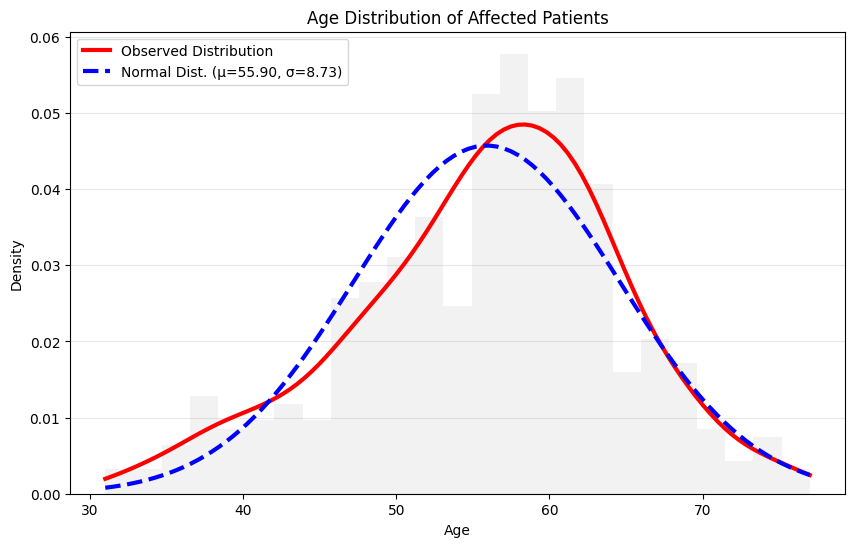

In [105]:
age_affected = df1.loc[df1['HeartDisease'] == 1, 'Age'].dropna()
mu, std = age_affected.mean(), age_affected.std()
plt.figure(figsize=(10, 6))

xmin, xmax = age_affected.min(), age_affected.max()
x = np.linspace(xmin, xmax, 100)
kde = gaussian_kde(age_affected)

plt.plot(x, kde(x), color='red', linewidth=3, label='Observed Distribution')
p = norm.pdf(x, mu, std)
plt.plot(x, p, color='blue', linewidth=3, linestyle='--', label=f'Normal Dist. (μ={mu:.2f}, σ={std:.2f})')
plt.hist(age_affected, bins=25, density=True, alpha=0.1, color='gray')
plt.title("Age Distribution of Affected Patients")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Here, we can observe that the distribution is right-skewed relative to the expected normal distribution, indicating that the risk of heart disease increases with age.

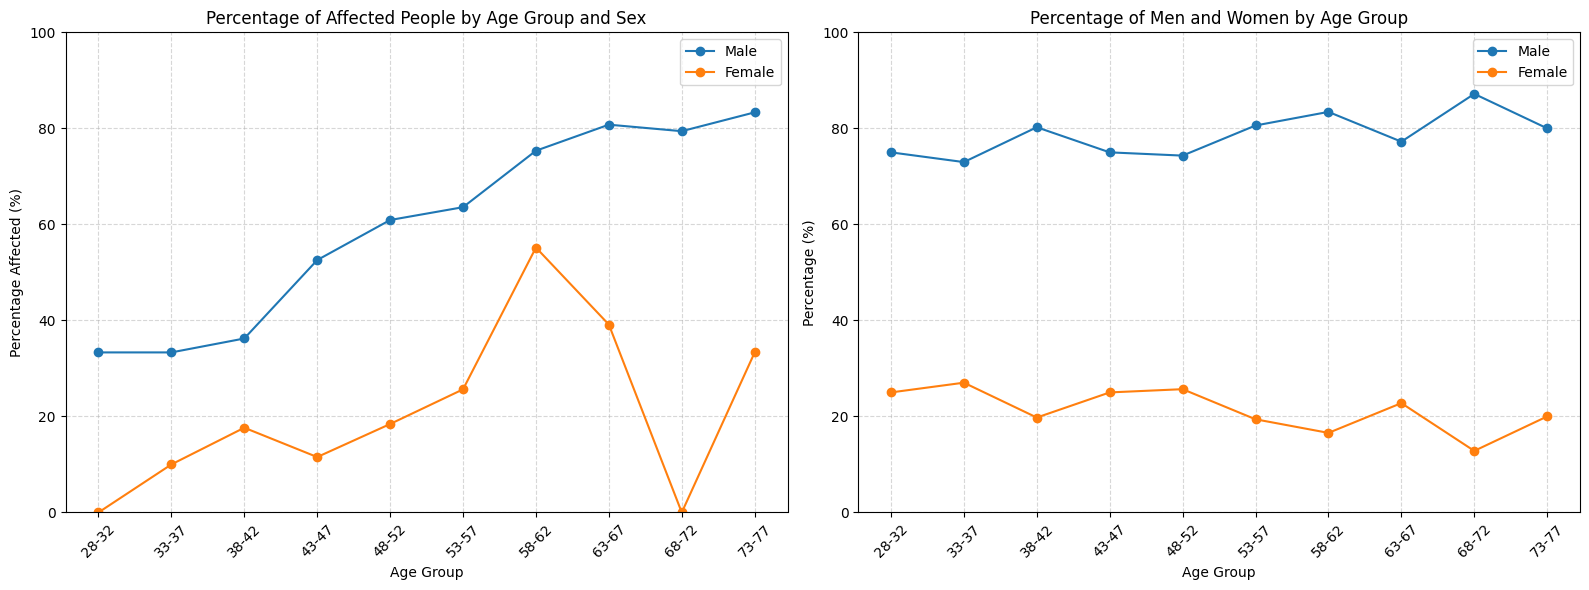

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
step = 5
min_age = int(df1["Age"].min())
max_age = int(df1["Age"].max())
bins = np.arange(min_age, max_age + step, step)
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]
df1["AgeGroup"] = pd.cut(df1["Age"], bins=bins, labels=labels, right=False)

grouped_aff = df1.groupby(["AgeGroup", "Sex"])["HeartDisease"].agg(['sum', 'count'])
grouped_aff['PercentageAffected'] = (grouped_aff['sum'] / grouped_aff['count'] * 100)
pivot_aff = grouped_aff['PercentageAffected'].unstack(level=1)

axes[0].plot(pivot_aff.index, pivot_aff['M'], marker='o', label='Male')
axes[0].plot(pivot_aff.index, pivot_aff['F'], marker='o', label='Female')

axes[0].set_title("Percentage of Affected People by Age Group and Sex")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Percentage Affected (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

grouped = df1.groupby(["AgeGroup", "Sex"]).size().unstack(fill_value=0)
percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

axes[1].plot(percentages.index, percentages['M'], marker='o', label='Male')
axes[1].plot(percentages.index, percentages['F'], marker='o', label='Female')

axes[1].set_title("Percentage of Men and Women by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


The analysis also shows that men constitute the majority of affected individuals in every age group, and their proportion increases consistently with age. **In the age range of 73–77, more than 80% of men are affected by the disease**. In contrast, **the proportion of affected women peaks in the 58–62 age group and declines thereafter**, which may be explained by a lower survival rate among women older than 62 (requires further investigation). This again support the idea that **being a man (especially old) is a huge risk factor for heart disease**.  
  
After evaluating the structure of the individuals in our dataset, we can proceed to examine the relationship between other features and the manifestation of heart disease.

# Nominal and Ordinal Data

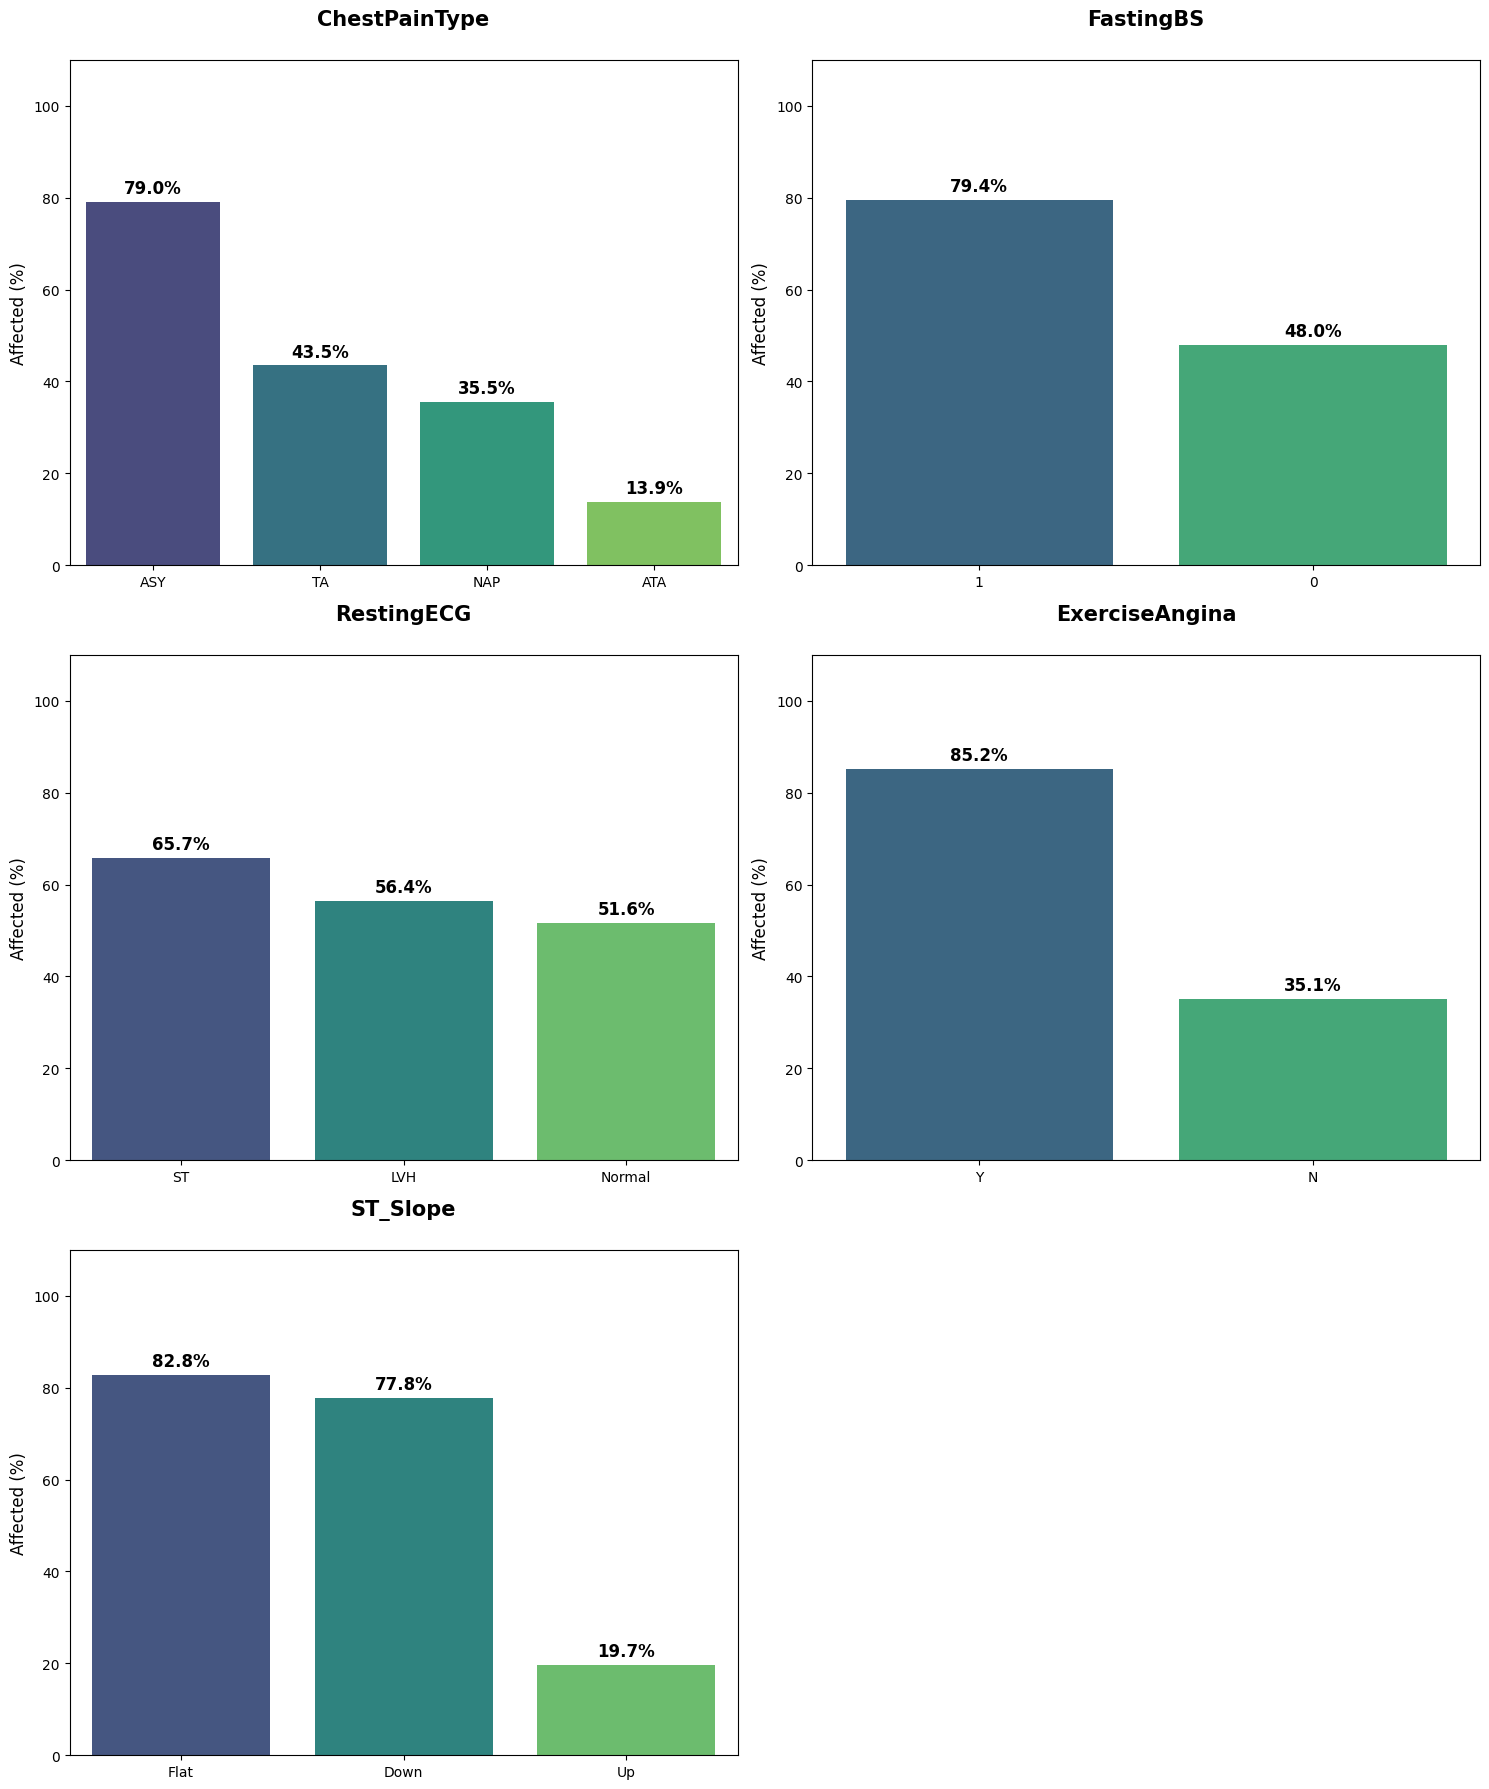

In [107]:
cat_cols = ['ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_cols = 2
num_rows = math.ceil(len(cat_cols) / num_cols)

plt.figure(figsize=(15, 6 * num_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    
    order = df1.groupby(col)['HeartDisease'].mean().sort_values(ascending=False).index
    
    ax = sns.barplot(
        data=df1, 
        x=col, 
        y='HeartDisease', 
        order=order,
        palette='viridis', 
        errorbar=None,
        estimator=lambda x: np.mean(x) * 100
    )
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold')

    plt.title(f'{col}', fontsize=15, fontweight='bold', pad=25)
    plt.ylabel('Affected (%)', fontsize=12)
    plt.xlabel('') 
    
    plt.ylim(0, 110)
    ax.grid(False)

plt.tight_layout()
plt.show()

1. **ChestPainType**:
* The highest percentage of affected individuals is observed in the asymptomatic group (79%).
* In all other groups, the proportion of affected individuals is lower, with the lowest level recorded in the typical angina group (13.9%).
* This suggests that asymptomatic presentation (absence of chest pain, ASY) is most strongly associated with heart disease.
2. **FastingBS**:
* The proportion of affected individuals is 31.4% higher in the group with elevated fasting blood sugar, suggesting that this may be a risk factor.
3. **RestingECG**:
* The proportion of affected individuals varies from 51.9% to 65.7% across groups, indicating that this factor may have a weaker influence compared to others.
4. **ExerciseAngina**:
* The proportion of affected individuals is 50.1% higher in the group exhibiting exercise-induced angina, indicating a strong association with heart disease.
5. **ST_Slope**:
* Groups with down or flat ST slope show high proportions of affected individuals (77.8% and 82.8%, respectively), which are approximately four times higher than in the group with an up ST slope.
* This indicates that down and flat ST slope are strongly associated with heart disease.
  
  
 
**Conclusion**: ChestPainTYpe='ASY', FastingBS=1, ExerciseAngina=1, and ST_Slope=down/low are most likely significant risk factors for heart disease.

## Relation with the sex

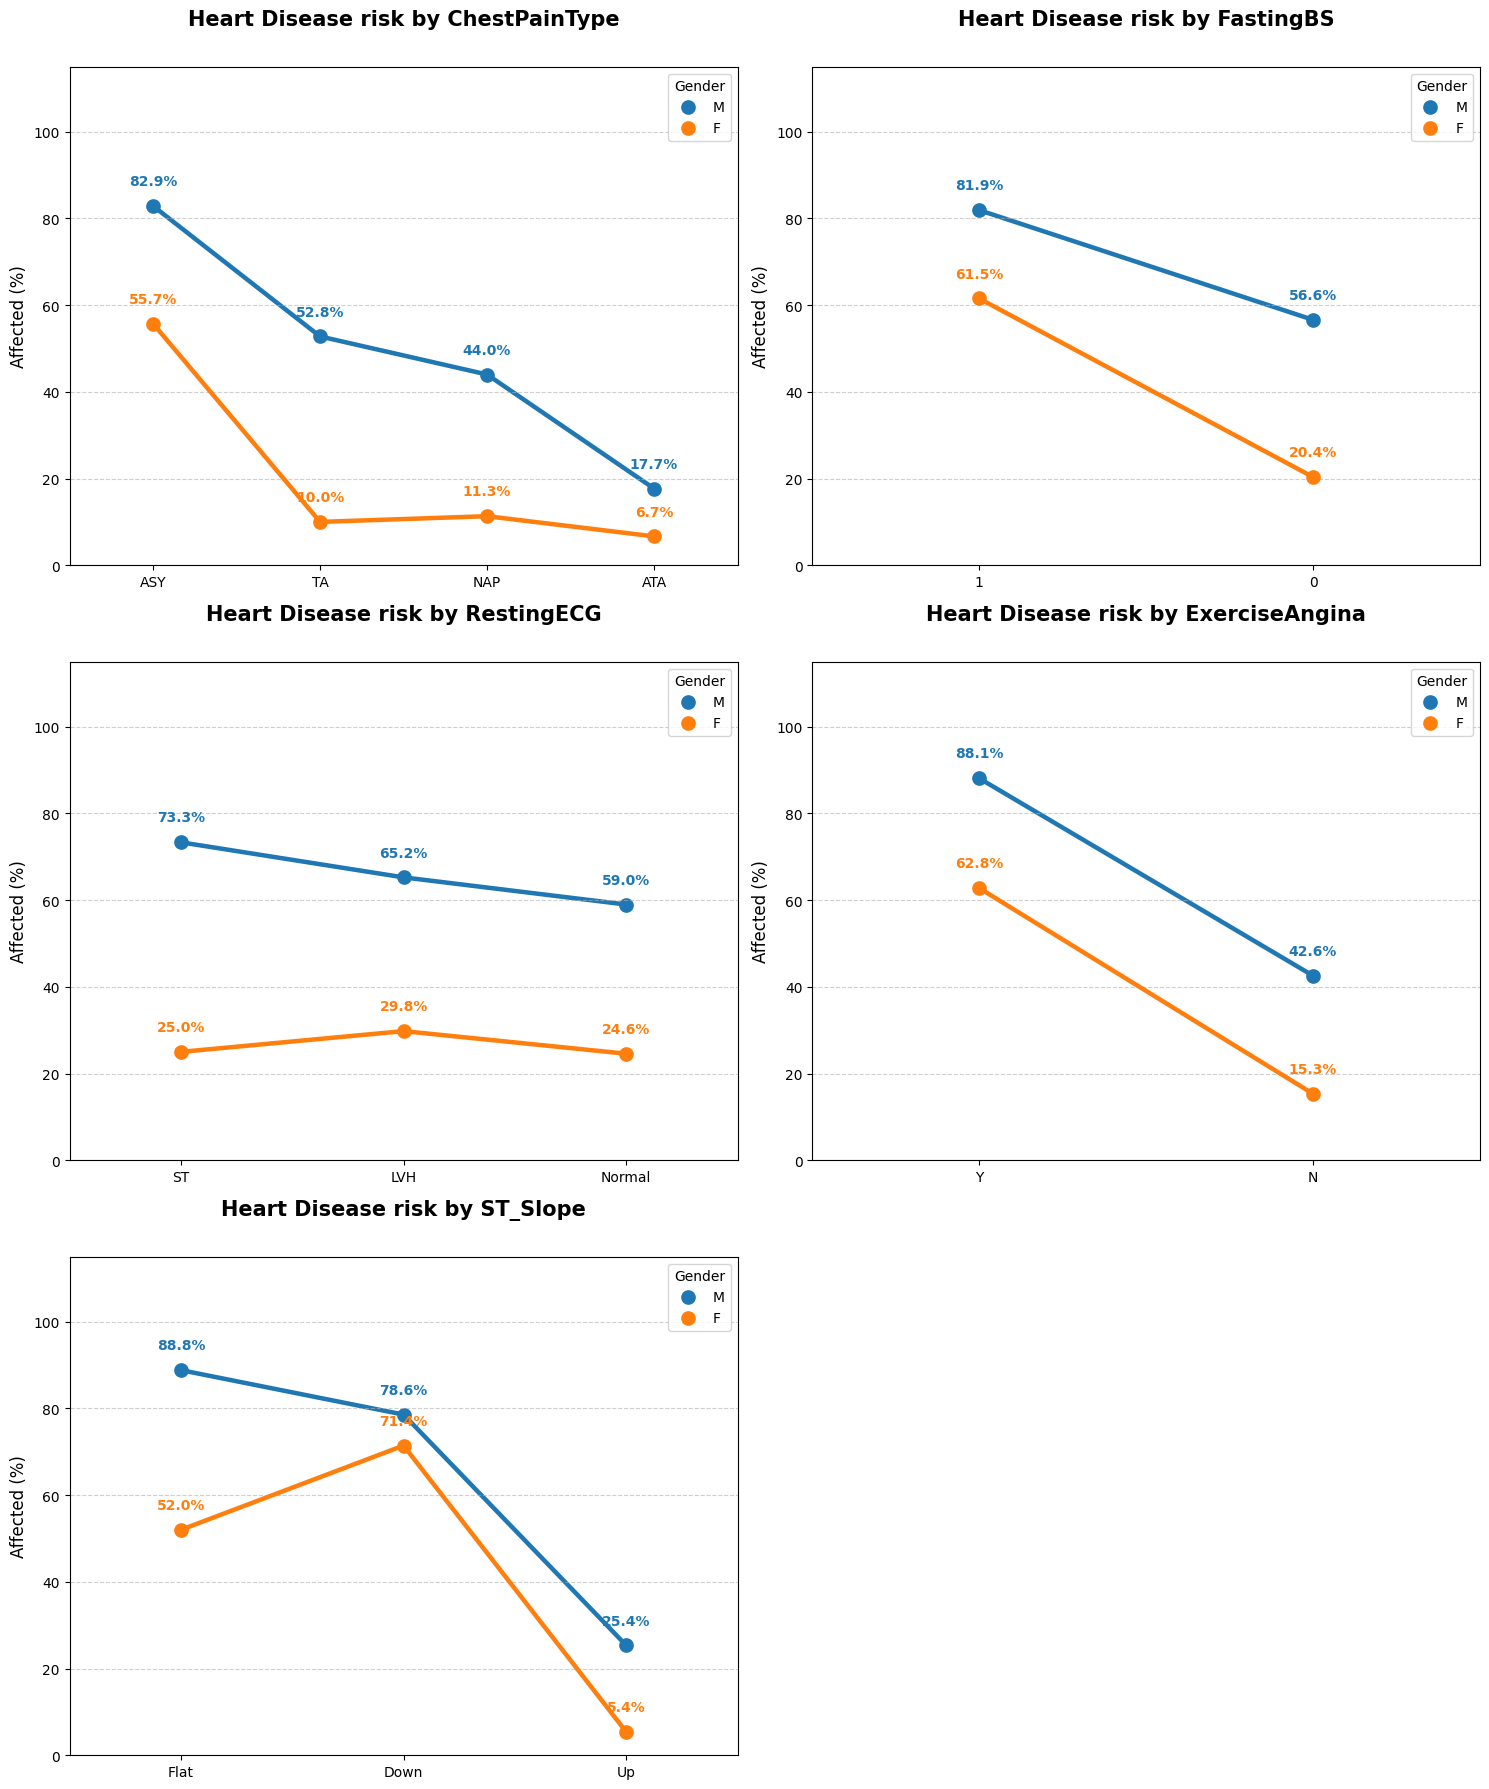

In [108]:
cat_cols = ['ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_cols = 2
num_rows = math.ceil(len(cat_cols) / num_cols)

plt.figure(figsize=(15, 6 * num_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    
    order = df1.groupby(col)['HeartDisease'].mean().sort_values(ascending=False).index
    
    ax = sns.pointplot(
        data=df1, 
        x=col, 
        y='HeartDisease', 
        hue='Sex',
        order=order,
        palette={'M': '#1f77b4', 'F': '#ff7f0e'},
        markers='o',
        scale=1.2,
        errorbar=None,
        estimator=lambda x: np.mean(x) * 100
    )
    
    for sex in df1['Sex'].unique():
        subset = df1[df1['Sex'] == sex].groupby(col)['HeartDisease'].mean() * 100
        subset = subset.reindex(order)
        for idx, val in enumerate(subset):
            if not np.isnan(val):
                ax.annotate(f'{val:.1f}%', 
                            (idx, val), 
                            textcoords="offset points", 
                            xytext=(0, 15), 
                            ha='center', 
                            fontsize=10, 
                            fontweight='bold',
                            color='#1f77b4' if sex == 'M' else '#ff7f0e')

    plt.title(f'Heart Disease risk by {col}', fontsize=15, fontweight='bold', pad=30)
    plt.ylabel('Affected (%)', fontsize=12)
    plt.xlabel('') 
    
    plt.ylim(0, 115)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='Gender', loc='upper right')

plt.tight_layout()
plt.show()

From these plots, we can see that the influence of certain factors is approximately equal for both men and women, as seen in ExerciseAngina and ChestPainType='ASY'. However, **in the case of FastingBS, the percentage of affected females increases more significantly in the group with elevated blood sugar**. Regarding ST_Slope, the risk increases drastically for both sexes when the slope is "Down." Interestingly, **the risk is higher for men with a flat slope, whereas the percentage of affected women actually decreases in that same category**
.

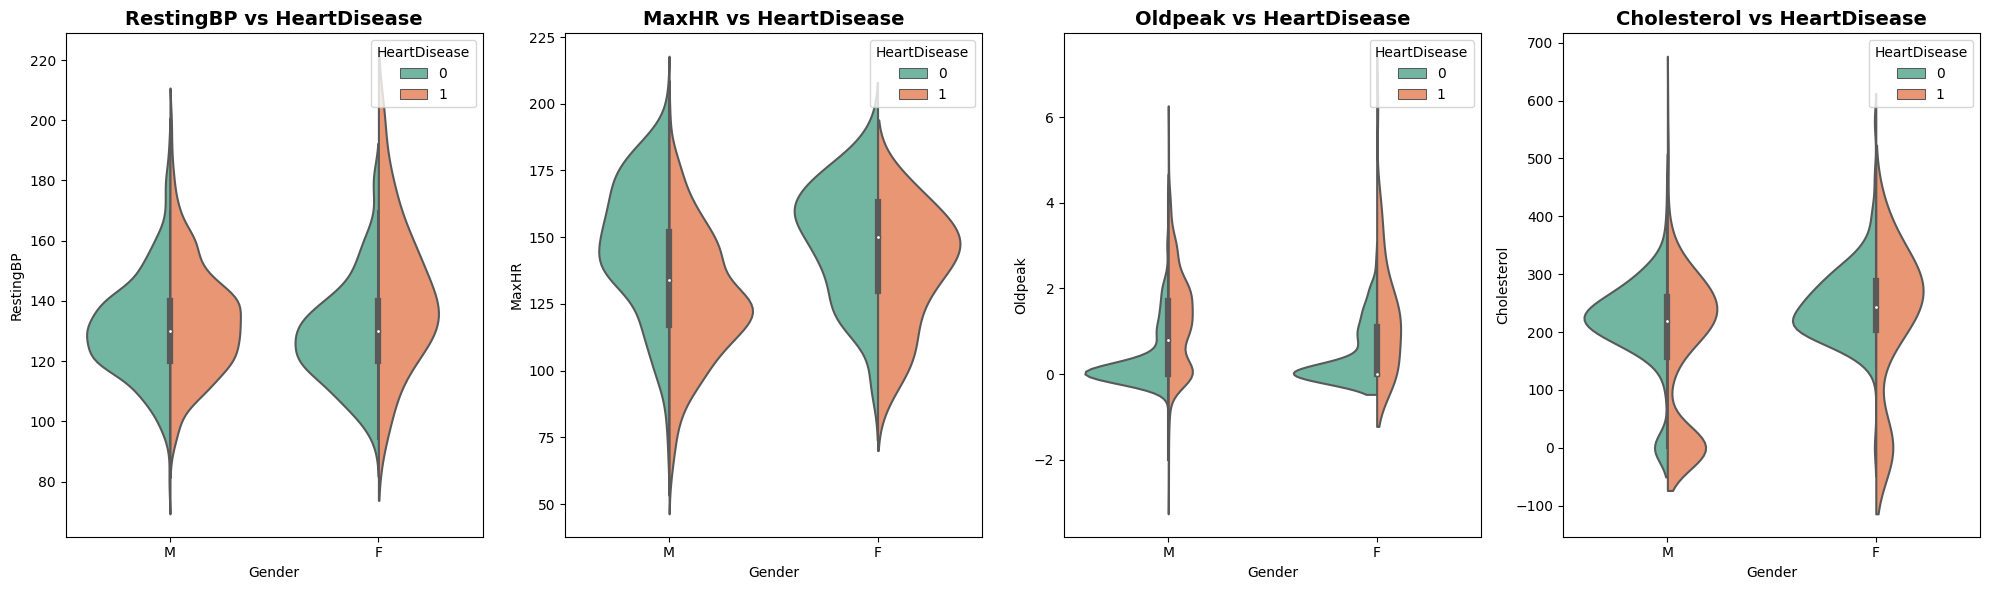

In [109]:
cont_cols = ['RestingBP', 'MaxHR', 'Oldpeak',  'Cholesterol']

fig, axes = plt.subplots(1, len(cont_cols), figsize=(20, 6))

for i, col in enumerate(cont_cols):
    sns.violinplot(
        data=df1, 
        x="Sex", 
        y=col, 
        hue="HeartDisease", 
        split=True, 
        ax=axes[i], 
        palette="Set2"
    )
    
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

* The plots show that **RestingBP varies only slightly within each sex group**, suggesting it is likely not a primary risk factor for heart disease in this specific dataset.  
* We also observe that **in the affected group, MaxHR tends to be lower**; notably, this downward trend is stronger in the male group.  
* **Oldpeak values for healthy individuals are highly concentrated at 0, whereas any deviation from zero to positive values correlates with a significantly higher number of affected people**.  
* The Cholesterol data is difficult to interpret due to the high frequency of zero values in the affected group, which skews the results. If we omit these zeros, the distribution between healthy and affected groups varies only slightly. Consequently, for this dataset, we can assume this factor is less significant than the others.

# Correlations and Association

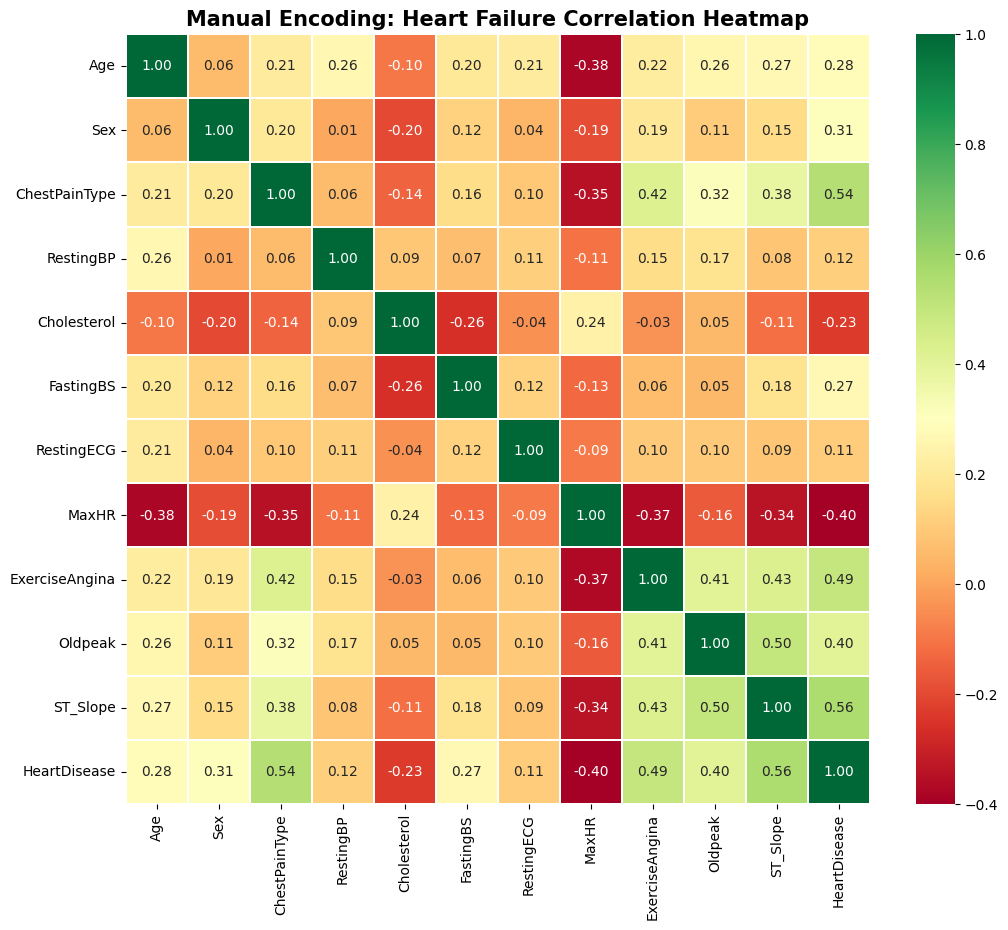

In [110]:

mapping = {
    'Sex': {'F': 0, 'M': 1},
    'ExerciseAngina': {'N': 0, 'Y': 1},
    'ChestPainType': {'ATA': 0, 'NAP': 1, 'TA': 2, 'ASY': 3},
    'RestingECG': {'Normal': 0, 'LVH': 1, 'ST': 2},
    'ST_Slope': {'Up': 0, 'Flat': 1, 'Down': 2}
}

df_encoded = df_final.copy()

for col, map_values in mapping.items():
    df_encoded[col] = df_encoded[col].map(map_values)

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='RdYlGn', linewidths=0.2, fmt='.2f')
plt.title('Manual Encoding: Heart Failure Correlation Heatmap', fontsize=15, fontweight='bold')
plt.show()

* Heart disease is most strongly associated with downsloping or flat ST segments, asymptomatic chest pain type, and the presence of exercise-induced angina.
* A weaker but still significant correlation is observed with male sex, older age, and elevated fasting blood sugar levels.

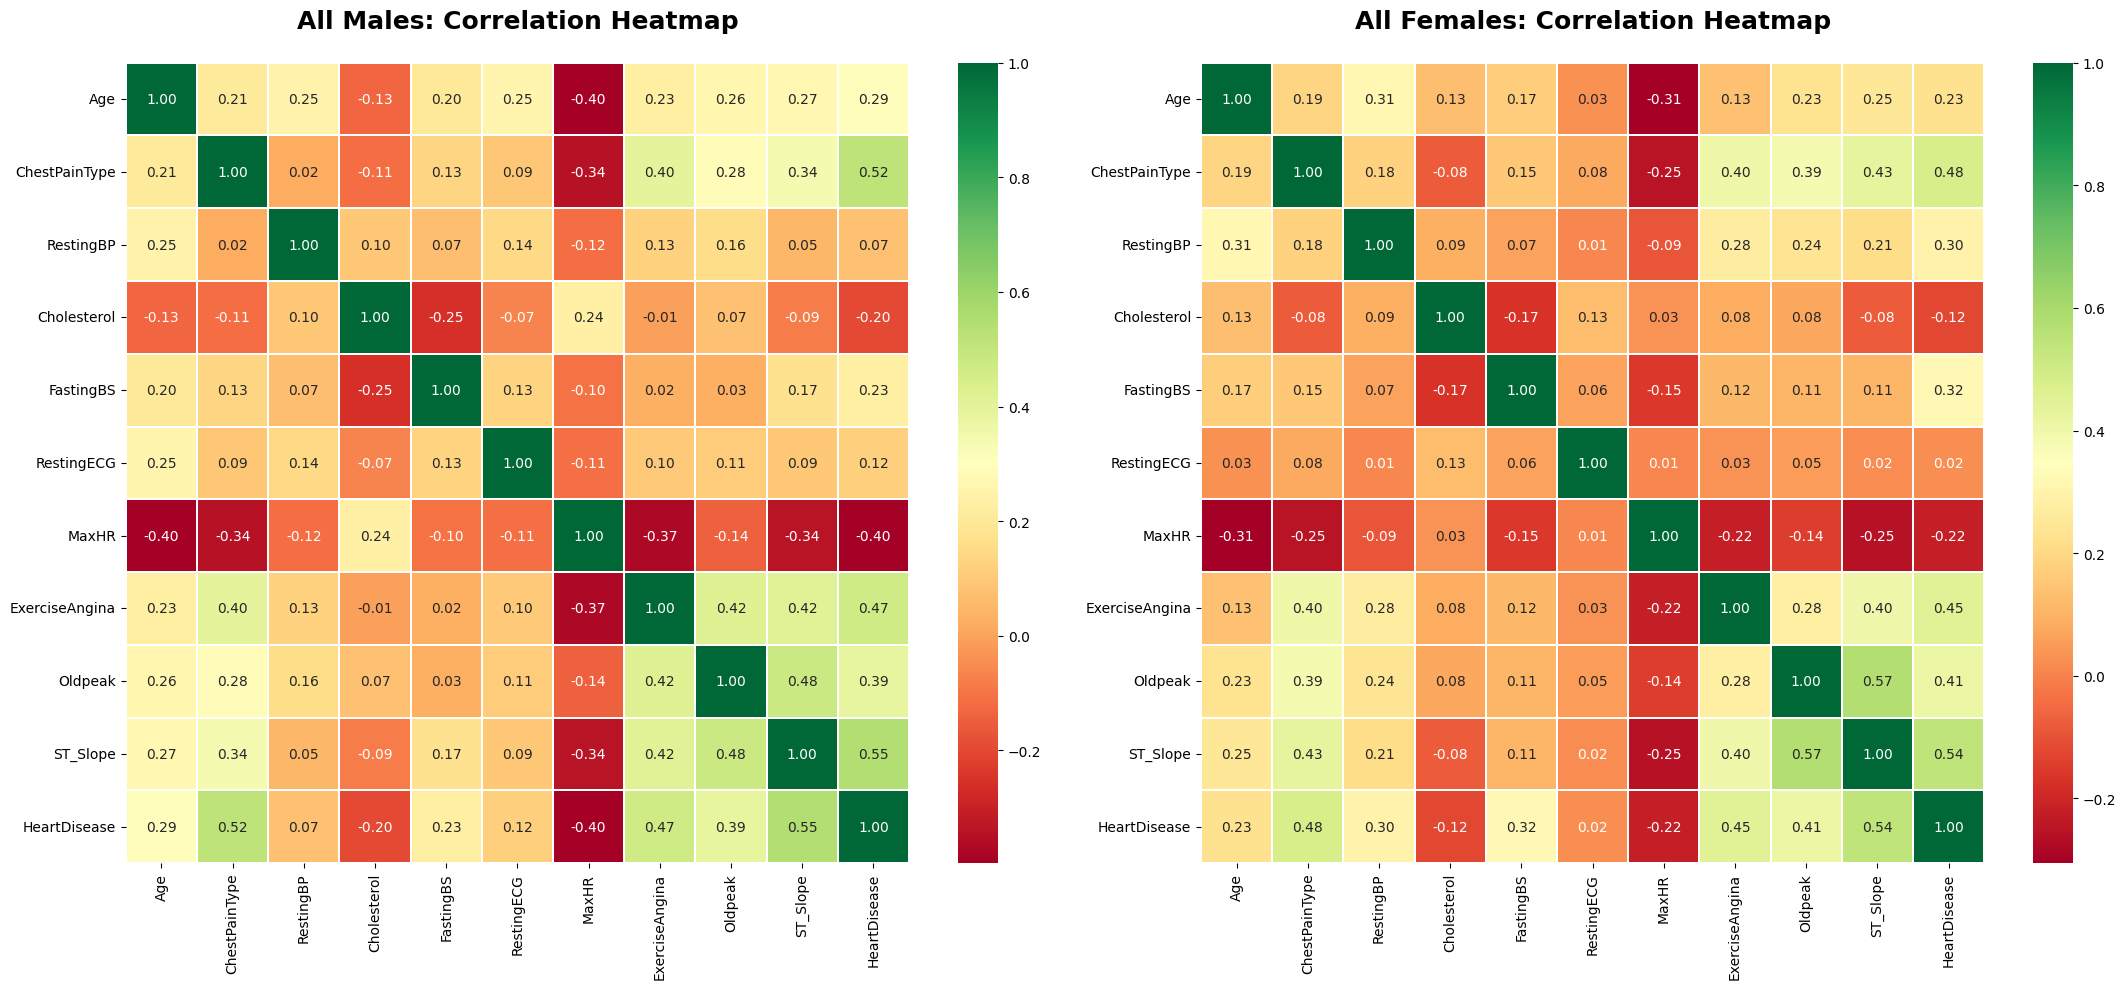

In [112]:
df_encoded = df_final.copy()
for col, map_values in mapping.items():
    df_encoded[col] = df_encoded[col].map(map_values)

df_male = df_encoded[df_encoded['Sex'] == 1].drop(['Sex'], axis=1)
df_female = df_encoded[df_encoded['Sex'] == 0].drop(['Sex'], axis=1)

f, ax = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(df_male.corr(), 
            annot=True, 
            cmap='RdYlGn', 
            linewidths=0.2, 
            fmt='.2f', 
            ax=ax[0])
ax[0].set_title('All Males: Correlation Heatmap', fontsize=18, fontweight='bold', pad=25)

sns.heatmap(df_female.corr(), 
            annot=True, 
            cmap='RdYlGn', 
            linewidths=0.2, 
            fmt='.2f', 
            ax=ax[1])
ax[1].set_title('All Females: Correlation Heatmap', fontsize=18, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

Here we can see that women show more association with HeartDisease for alevated FastingBS and higher RestinBP, and less association for lower MaxHR than men.

## Suggestion for Possible Feature Engineering or Variable Encoding
1. **Age** -> numerical continuous data, may be normalized linearly
2. **Sex** -> nominal data, can be binary encoded ('F' = 0, 'M' = 1)
3. **ChestPainType** -> categorical data, can be one-hot encoding ('ATA'= 0, 'NAP' = 1, 'TA' = 2, 'ASY' = 3)
4. **RestingBP** -> numerical continuos data, may be normalized linearly
5. **Cholesterol** -> numerical contunuos data, for this dataset the best solution is to omit the zero values in it (because imputation lead to distribution extremly biased toward the mean/median in the group of interest)
6. **FastingBS** -> categorical data, which is already binary encoded, no further transfromation is needed
7. **Resting ECG** -> categorical data, can use one-hot encoding ('Normal' = 1, 'LVH' = 2, 'ST' = 3)
8. **ExerciseAngina** -> categorical data, which is already binary encoded, no further transfromation is needed
9. **Old peak** -> numerical continuous data, can be either normalized or standardized
10. **ST_Slope** -> categorical data, can be one-hot encoded ('Up' = 1, 'Flat' = 2, 'Down' = 3)

# Conclusions
* The analyzed dataset doesn't contain null values and non-numerical data in columns where it supposed to be numerical data
* In the RestingBP one zero value are present and can be replaced by the mean or the median without affecting the distribution
* In the Cholesterol column many zero values are present in the group of affected people, which makes this data hard to interpret. The best technical solution is to omit this zero values, then for existing data wi will have that distribution of affected individiuals differs only slightly from the distribution of healthy individuals in the dataset.
* Among the clinical features:
1. 3 showed strong correlation with heart disease: ST_Slope(flat or down), ChestPainType (asymptotical), ExerciseAngina (observed), and MaxHR(lower).
2. 2 showed moderatly less correlation overall: Age(older) and Sex(male), but Sex is important in terms of correlation of HeartDisease with other treats in sex-specific groups.
* Following this exploratory analysis and after the implementation of the previously described suggestions, the dataset can be used for the modeling